## exp04_augs.ipynb - Влияние аугментаций на обучение CNN
**Цель:** Экспериментально оценить, как различные стратегии аугментации влияют на качество  
**Данные:** `data/train/`, `data/test/`   
**Подход:** Фиксируем архитектуру, гиперпараметры и ранний стоп. Меняем только состав трансформаций для train-данных. Сравниваем по F1-macro и кривым обучения

Начало эксперимента CNN_aug_base. Число эпох = 50. Устройство: cuda
Эпоха 1. Валидационные метрики: acc = 0.2513937282229965, f1 = 0.057397426463276384
Эпоха 2. Валидационные метрики: acc = 0.24024390243902438, f1 = 0.08977128044342253
Эпоха 3. Валидационные метрики: acc = 0.18327526132404182, f1 = 0.08460872266177952
Эпоха 4. Валидационные метрики: acc = 0.17299651567944252, f1 = 0.05429333582986261
Эпоха 5. Валидационные метрики: acc = 0.1588850174216028, f1 = 0.06617675670688432
Эпоха 6. Валидационные метрики: acc = 0.23623693379790942, f1 = 0.13637810484363175
Эпоха 7. Валидационные метрики: acc = 0.25609756097560976, f1 = 0.12373723746690565
Эпоха 8. Валидационные метрики: acc = 0.2707317073170732, f1 = 0.10000353943909442
Эпоха 9. Валидационные метрики: acc = 0.2951219512195122, f1 = 0.17883250495379704
Эпоха 10. Валидационные метрики: acc = 0.30853658536585366, f1 = 0.14232755163141755
Эпоха 11. Валидационные метрики: acc = 0.34146341463414637, f1 = 0.18629823359921516
Эпоха 12.

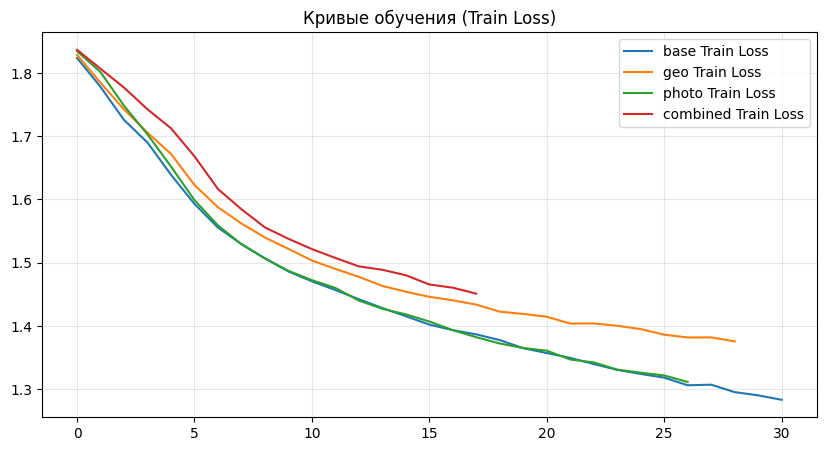

In [1]:
import matplotlib.pyplot as plt
from src.data.loader import create_dataloaders
from src.models.cnn import train_cnn, eval_cnn
from src.constants import DATA_PATH, FIGURES_PATH
from src.utils.experiment_logger import log_experiment
from src.features.image_transforms import get_train_transform

augs = {
    "base": get_train_transform("base"),
    "geo": get_train_transform("geo"),
    "photo": get_train_transform("photo"),
    "combined": get_train_transform("combined"),
}

batch_size = 64
experiment_name = "cnn_variants"
plt.figure(figsize=(10,5))
for aug_name, tf in augs.items():
    lr = 1e-3
    wd = 1e-4
    patience = 5
    epochs=50

    train_loader, val_loader, test_loader = create_dataloaders(DATA_PATH, batch_size=batch_size, train_transform=tf)

    model_name = f"CNN_aug_{aug_name}"
    model, hist = train_cnn(train_loader, val_loader, epochs=epochs, lr=lr, name=model_name, 
                                weight_decay=wd, patience=patience)
    
    plt.plot(hist["train_loss"], label=f"{aug_name} Train Loss")
    
    y_true, y_pred = eval_cnn(model, test_loader)
            
    training_cfg = {
        "experiment_name": experiment_name,
        "model_name": model_name,
        "epochs": len(hist["train_loss"]),
        "lr": lr,
        "wd": wd,
        "patience": patience,
        "batch_size": batch_size,
        "augmentation": aug_name
    }

    log_experiment(experiment_name, model_name, y_true, y_pred, training_cfg)
    

plt.title("Кривые обучения (Train Loss)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{FIGURES_PATH}/augs_curves.png")
plt.show()